In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import random
import numpy as np
from datasets import load_dataset
import re
%matplotlib inline

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
raw_dataset = load_dataset("imdb")
train_raw = raw_dataset["train"]
test_raw = raw_dataset["test"]

def simple_tokenizer(text):
    '''
作用：将原始文本字符串拆分为单词列表（Tokenization）。
细节：
使用 text.lower() 将所有文字转为小写。
使用正则表达式re.findall(r"[a-z]+(?:'[a-z]+)?", ...) 
提取纯英文字符单词，并处理了包含撇号的缩写词（如 "don't"）。'''
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

def build_vocab(texts, max_size=50000):
    '''
作用：根据训练文本构建词汇表，建立单词到数字索引的映射。
细节：
统计所有单词出现的频率。
按频率降序排列，选取前 max_size 个常用词。
预留了两个特殊标记：<unk>（未知词，索引为 0）
    和 <pad>（填充字符，索引为 1），用于处理词表外词汇和等长对齐。'''
    word_freq = {}
    for text in texts:
        for token in simple_tokenizer(text):
            word_freq[token] = word_freq.get(token, 0) + 1
    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
    vocab = {"<unk>": 0, "<pad>": 1}
    for word, _ in sorted_words[:max_size - 2]:
        vocab[word] = len(vocab)
    return vocab

def numericalize(text, max_length=256):
    '''
作用：将文本转换为模型可以理解的数字序列（数值化）。
细节：
调用 simple_tokenizer 得到分词结果。
在 vocab 中查找每个词的索引，找不到则用 UNK_IDX 代替。
通过 max_length 限制序列长度，防止计算量过大。'''
    tokens = simple_tokenizer(text)
    indices = [vocab.get(token, UNK_IDX) for token in tokens]
    return indices[:max_length]

def get_label(label_item):
    '''作用：将标签标准化为整数。
细节：将 "neg"（负面）映射为 0，"pos"（正面）映射为 1。'''
    if isinstance(label_item, int):
        return label_item
    label_map = {"neg": 0, "pos": 1}
    return label_map.get(label_item, 0)

vocab = build_vocab(train_raw["text"], max_size=50000)
PAD_IDX = vocab["<pad>"]
UNK_IDX = vocab["<unk>"]

train_data = [(get_label(sample["label"]), numericalize(sample["text"])) for sample in train_raw]
test_data = [(get_label(sample["label"]), numericalize(sample["text"])) for sample in test_raw]

In [4]:
def collate_fn(batch):
    '''作用：用于 DataLoader 在整理一个批次（Batch）数据时的自定义逻辑。
细节：
由于不同评论的长度不一，使用 pad_sequence 函数以 PAD_IDX 进行填充
，使同一个 Batch 内的所有序列长度一致。
batch_first=True 表示输出张量的形状为 (batch_size, seq_len)。'''
    labels, sequences = zip(*batch)
    # 获取每个句子的真实长度（限制最小长度为1，防止空序列报错）
    lengths = torch.tensor([max(1, len(seq)) for seq in sequences],
                            dtype=torch.long)
    sequences_padded = pad_sequence(
        [torch.tensor(seq, dtype=torch.long) for seq in sequences],
        batch_first=True,
        padding_value=PAD_IDX
    )
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    return sequences_padded, labels_tensor,lengths

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_fn, num_workers=0,pin_memory=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, collate_fn=collate_fn, num_workers=0)

In [5]:
class SentimentLSTM(nn.Module):
    # 定义一个名为 SentimentLSTM 的类，继承自 PyTorch 的基础模型类 nn.Module
    
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        # 类的初始化函数（构造函数）。接收词表大小、词向量维度、LSTM隐藏层维度、LSTM层数，以及可选的dropout率（默认0.3）
        super().__init__()
        # 调用父类 nn.Module 的初始化函数，这是编写 PyTorch 模型的标准要求
        self.hidden_dim = hidden_dim# 将传入的隐藏层维度保存为类的属性，方便后续使用
        self.num_layers = num_layers# 将传入的层数保存为类的属性
        # 假设 PAD_IDX 是你在外部定义好的 padding 索引（例如 0）
        PAD_IDX = 0 
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        # 实例化词嵌入层。将词索引映射为密集向量。
        # padding_idx=PAD_IDX 表示在遇到填充字符时，其对应的词向量全为0，且在训练中不更新。
        
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0, bidirectional=False)
        # 实例化 LSTM 层。
        # embed_dim: 输入特征维度；hidden_dim: 隐藏状态维度；num_layers: LSTM 堆叠层数。
        # batch_first=True: 要求输入和输出的张量形状的第一维是 batch_size (即 [batch_size, seq_len, feature])。
        # dropout: 如果层数大于1，则在 LSTM 层之间添加 dropout；如果只有1层则设为0。
        # bidirectional=False: 单向 LSTM。
        
        self.dropout = nn.Dropout(dropout)
        # 实例化一个 Dropout 层，用于在全连接层之前防止过拟合。
        
        self.fc = nn.Linear(hidden_dim, 2)
        # 实例化一个全连接层（线性层），将 LSTM 的隐藏状态（维度 hidden_dim）映射到 2 个类别。
    def forward(self, x, text_lengths):
        # 前向传播现在多接收一个参数 `text_lengths`，表示当前 batch 中每个句子的真实长度
        # x 形状: [batch_size, seq_len]
        # text_lengths 形状: [batch_size]，包含一维的整数长度值
        embedded = self.embedding(x)# 数据通过嵌入层。输出形状变为 [batch_size, seq_len, embed_dim]
        
        # 将填充后的序列“打包”
        # pack_padded_sequence 会压紧数据，忽略掉 <PAD> 标志，让 LSTM 只处理真实的单词。
        # enforce_sorted=False 允许 batch 内的句子长度不需要提前按降序排好（PyTorch 1.1+ 支持）
        # 注意：text_lengths 必须在 CPU 上，所以一般加上 .cpu()
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # 将“打包”后的数据传入 LSTM
        packed_output, (h_n, c_n) = self.lstm(packed_embedded)
        # 因为输入的是 packed sequence，LSTM 非常聪明，它返回的 h_n 自动就是【每个序列真正最后一个有效词】的隐藏状态！
        # h_n 形状依然是: [num_layers, batch_size, hidden_dim]
        
        return self.fc(self.dropout(h_n[-1]))
        # 将其输入 Dropout 层，然后再输入全连接层 self.fc，返回最终的分类逻辑值。
model = SentimentLSTM(len(vocab), embed_dim=100, hidden_dim=128, num_layers=1, dropout=0.2)

for name, param in model.named_parameters():
    if 'weight_ih' in name:
        nn.init.xavier_uniform_(param)
    elif 'weight_hh' in name:
        nn.init.orthogonal_(param)
    elif 'bias' in name:
        nn.init.constant_(param, 0)
    elif 'weight' in name and 'embedding' not in name:
        nn.init.xavier_uniform_(param)

model = model.to(device)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1, min_lr=1e-7)
#当验证集准确率（mode='max'）在连续几轮内不再提升时，自动将学习率减半（factor=0.5）

In [9]:
def train_epoch(model, loader, criterion, optimizer, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for sequences, labels,lengths in loader:
        sequences, labels= sequences.to(device), labels.to(device)
        logits = model(sequences,lengths)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        
        total_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(logits.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for sequences, labels,lengths in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            logits = model(sequences,lengths)
            _, predicted = torch.max(logits.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return correct / total

In [ ]:
# 训练（15+15epochs）
epochs = 15
train_accs, val_accs = [], []
best_val_acc = 0.0
model_save_path = 'imdb_lstm_best.pth'

for epoch in range(epochs):
    _, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_acc = evaluate(model, test_loader)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_save_path)
        marker = ' ✓'
    else:
        marker = ''
    
    print(f'Epoch {epoch+1:2d}/{epochs} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%{marker}')

print(f'\n训练完成！最佳验证准确率：{best_val_acc:.4f}')#改进后86.13% 15epochs

Epoch  1/15 | Train Acc: 63.34% | Val Acc: 73.15% ✓
Epoch  2/15 | Train Acc: 74.50% | Val Acc: 77.13% ✓
Epoch  3/15 | Train Acc: 78.69% | Val Acc: 80.10% ✓
Epoch  4/15 | Train Acc: 82.23% | Val Acc: 83.02% ✓
Epoch  5/15 | Train Acc: 85.80% | Val Acc: 84.30% ✓
Epoch  6/15 | Train Acc: 87.68% | Val Acc: 84.55% ✓
Epoch  7/15 | Train Acc: 89.08% | Val Acc: 85.36% ✓
Epoch  8/15 | Train Acc: 90.58% | Val Acc: 85.62% ✓
Epoch  9/15 | Train Acc: 90.78% | Val Acc: 85.32%
Epoch 10/15 | Train Acc: 91.50% | Val Acc: 85.33%
Epoch 11/15 | Train Acc: 94.14% | Val Acc: 86.13% ✓
Epoch 12/15 | Train Acc: 95.07% | Val Acc: 86.12%
Epoch 13/15 | Train Acc: 95.65% | Val Acc: 86.11%
Epoch 14/15 | Train Acc: 97.12% | Val Acc: 86.02%
Epoch 15/15 | Train Acc: 97.81% | Val Acc: 85.76%

训练完成！最佳验证准确率：0.8613


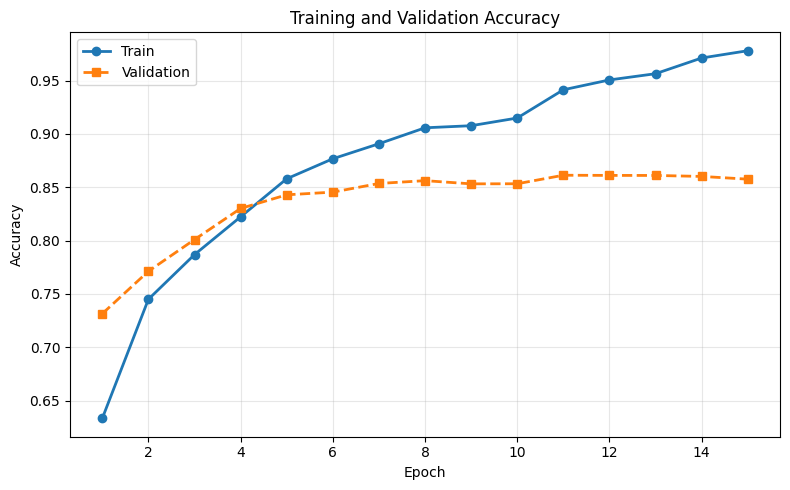

最佳验证准确率：0.8613 (Epoch 11)


In [11]:
# 可视化训练准确率
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(train_accs) + 1), train_accs, 'o-', label='Train', linewidth=2)
ax.plot(range(1, len(val_accs) + 1), val_accs, 's--', label='Validation', linewidth=2)
ax.set_title('Training and Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'最佳验证准确率：{best_val_acc:.4f} (Epoch {val_accs.index(best_val_acc) + 1})')

In [ ]:
# 预测
model.load_state_dict(torch.load(model_save_path, weights_only=True))
model.eval()

def predict_sentiment(text):
    indices = numericalize(text)
    if not indices:
        return '无法预测', 0.0
    tensor = torch.tensor([indices], dtype=torch.long).to(device)
    length = torch.tensor([len(indices)], dtype=torch.long)
    with torch.no_grad():
        probs = torch.softmax(model(tensor, length), dim=1)
        pred = torch.argmax(probs, dim=1).item()
        return '正面' if pred == 1 else '负面', probs[0][pred].item()

test_reviews = [
    "This movie is absolutely amazing! Best film I've ever seen.",
    "Terrible acting, boring plot, waste of time.",
    "Not bad, but could be better.",
    "A masterpiece of cinema. Highly recommended!",
    "You helped get my clothes dirty. What a good man!",#still wrong
    "Can't you do things a little better?",#right
    "Can't you do things better?"#wrong->right
]#测试用例

for review in test_reviews:
    sentiment, confidence = predict_sentiment(review)
    print(f'{sentiment} (置信度{confidence:.2%}): {review[:50]}...')

正面 (置信度99.55%): This movie is absolutely amazing! Best film I've e...
负面 (置信度99.96%): Terrible acting, boring plot, waste of time....
负面 (置信度71.82%): Not bad, but could be better....
正面 (置信度99.24%): A masterpiece of cinema. Highly recommended!...
正面 (置信度78.05%): You helped get my clothes dirty. What a good man!...
负面 (置信度54.16%): Can't you do things a little better?...
负面 (置信度53.51%): Can't you do things better?...
